## 후진제거법

### 라이브러리 호출

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

### 한글 폰트 오류

In [2]:
# 1. 한글 폰트 깨짐 방지
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드 

In [3]:
# 2. 데이터 로드 및 학습용 표준화 변수 선택
df = pd.read_csv('single variable_data.csv')

# preprocessor.ipynb에서 생성된 20개의 '_std' 표준화 변수만 선택
risk_cols_std = [col for col in df.columns if col.endswith('_std')]

# 후진제거법 알고리즘에 바로 투입할 데이터셋 구성
X_scaled = df[risk_cols_std]

print(f"후진제거법 학습용(std) 데이터 준비 완료: {X_scaled.shape}")

후진제거법 학습용(std) 데이터 준비 완료: (3448, 20)


### 후진제거법 진행

In [7]:
# 3. 후진제거법(Backward Elimination) 세팅
current_features = list(X_scaled.columns)
history = [] # 단계별 기록 저장

print(f"[클러스터링 후진제거법] 총 {len(current_features)}개 변수에서 탐색 시작.")

# 변수가 3개 남을 때까지 계속 범인(점수 깎는 변수)을 찾아 탈락시킴
while len(current_features) > 3:
    best_step_score = -1
    feature_to_drop = None
    best_step_k = -1
    
    # 현재 남은 변수들 중 '어떤 놈을 뺐을 때 점수가 제일 오를까?' 하나씩 다 빼서 테스트
    for feature in current_features:
        temp_features = [f for f in current_features if f != feature]
        temp_data = X_scaled[temp_features]
        
        # 임시 데이터로 최적의 K 탐색 (속도를 위해 K=2~7까지만 탐색)
        temp_best_score = -1
        temp_best_k = -1
        for k in range(2, 8):
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(temp_data)
            score = silhouette_score(temp_data, labels)
            
            if score > temp_best_score:
                temp_best_score = score
                temp_best_k = k
                
        # 이번 단계에서 최고 점수를 갱신했다면, 해당 변수를 '제거 후보'로 등록
        if temp_best_score > best_step_score:
            best_step_score = temp_best_score
            feature_to_drop = feature
            best_step_k = temp_best_k
            
    # 1-Step 완료: 가장 점수를 많이 깎아먹던 범인 확정 및 영구 탈락
    current_features.remove(feature_to_drop)
    history.append({
        'dropped_feature': feature_to_drop,
        'remaining_count': len(current_features),
        'best_k': best_step_k,
        'silhouette': best_step_score
    })
    
    print(f"[-] 탈락 변수: {feature_to_drop} | 남은 변수: {len(current_features)}개 | 최적 K: {best_step_k} | 실루엣 점수: {best_step_score:.4f}")

[클러스터링 후진제거법] 총 20개 변수에서 탐색 시작.
[-] 탈락 변수: risk_digital_std | 남은 변수: 19개 | 최적 K: 2 | 실루엣 점수: 0.1332
[-] 탈락 변수: risk_group_std | 남은 변수: 18개 | 최적 K: 2 | 실루엣 점수: 0.1435
[-] 탈락 변수: risk_aging_rate_std | 남은 변수: 17개 | 최적 K: 3 | 실루엣 점수: 0.1561
[-] 탈락 변수: risk_infra_gap_std | 남은 변수: 16개 | 최적 K: 3 | 실루엣 점수: 0.1691
[-] 탈락 변수: risk_unemployed_std | 남은 변수: 15개 | 최적 K: 4 | 실루엣 점수: 0.1743
[-] 탈락 변수: risk_health_std | 남은 변수: 14개 | 최적 K: 4 | 실루엣 점수: 0.1899
[-] 탈락 변수: risk_alcohol_std | 남은 변수: 13개 | 최적 K: 2 | 실루엣 점수: 0.2080
[-] 탈락 변수: risk_age_std | 남은 변수: 12개 | 최적 K: 2 | 실루엣 점수: 0.2293
[-] 탈락 변수: risk_housing_safety_std | 남은 변수: 11개 | 최적 K: 3 | 실루엣 점수: 0.2586
[-] 탈락 변수: risk_housing_env_std | 남은 변수: 10개 | 최적 K: 4 | 실루엣 점수: 0.2710
[-] 탈락 변수: risk_drug_std | 남은 변수: 9개 | 최적 K: 5 | 실루엣 점수: 0.2952
[-] 탈락 변수: risk_meet_std | 남은 변수: 8개 | 최적 K: 5 | 실루엣 점수: 0.3447
[-] 탈락 변수: risk_depression_std | 남은 변수: 7개 | 최적 K: 5 | 실루엣 점수: 0.4266
[-] 탈락 변수: risk_housing_tenure_std | 남은 변수: 6개 | 최적 K: 2 | 실루엣 점수: 0.6517
[-] 

In [8]:
# 4. 탐색 결과 데이터프레임 변환
history_df = pd.DataFrame(history)

### 결과 시각화

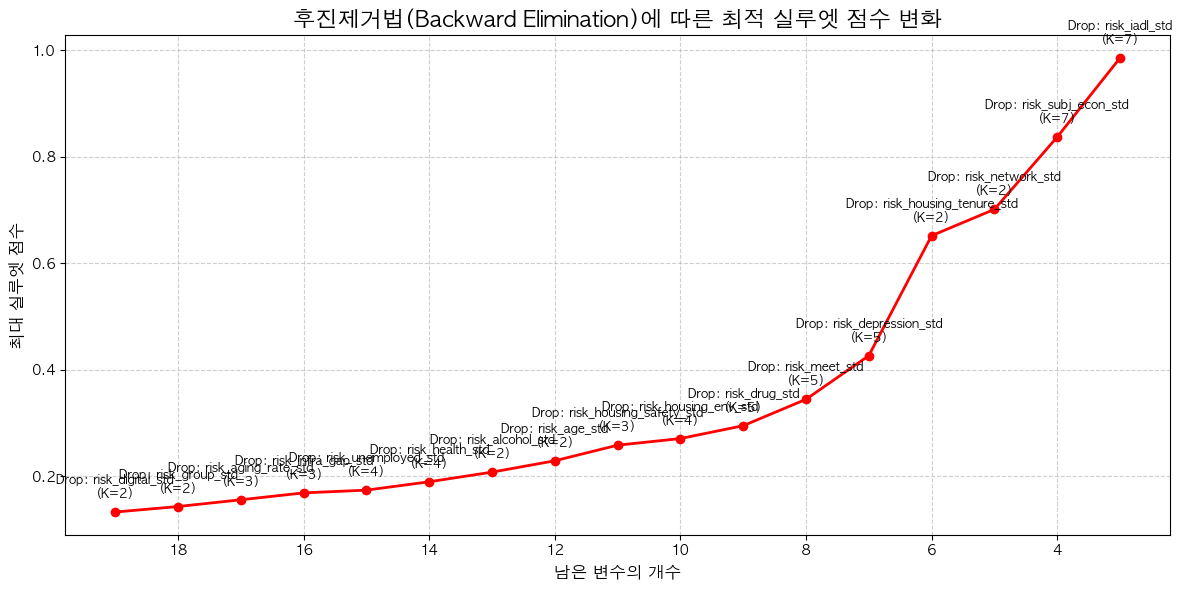

In [9]:
# 5. 시각화: 변수가 제거됨에 따라 실루엣 점수가 어떻게 변하는지 (Elbow Method)
plt.figure(figsize=(12, 6))
plt.plot(history_df['remaining_count'], history_df['silhouette'], marker='o', color='red', linestyle='-', linewidth=2)

# 각 점 위에 탈락된 변수 이름과 K값 적어주기
for i, row in history_df.iterrows():
    plt.annotate(f"Drop: {row['dropped_feature']}\n(K={row['best_k']})", 
                 (row['remaining_count'], row['silhouette']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.title('후진제거법(Backward Elimination)에 따른 최적 실루엣 점수 변화', fontsize=16)
plt.xlabel('남은 변수의 개수', fontsize=12)
plt.ylabel('최대 실루엣 점수', fontsize=12)

# 변수가 줄어드는 과정을 보여주기 위해 X축을 역순으로 뒤집음
plt.gca().invert_xaxis() 
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()